In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

# =========================
# LOAD DATA
# =========================

train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

# =========================
# TEXT + LABEL
# =========================

X_train = train_df["text"].astype(str)
y_train = train_df["label_id"]

X_val = val_df["text"].astype(str)
y_val = val_df["label_id"]

X_test = test_df["text"].astype(str)
y_test = test_df["label_id"]

# =========================
# TOKENIZE
# =========================

MAX_WORDS = 20000
MAX_LEN = 300

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

train_seq = tokenizer.texts_to_sequences(X_train)
val_seq = tokenizer.texts_to_sequences(X_val)
test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post')
X_val_pad = pad_sequences(val_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(test_seq, maxlen=MAX_LEN, padding='post')

# =========================
# BUILD MODEL
# =========================

model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),

    Bidirectional(LSTM(64)),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# =========================
# TRAIN
# =========================

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=32
)

# =========================
# EVALUATE
# =========================

y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 140s 413ms/step - accuracy: 0.8957 - loss: 0.2653 - val_accuracy: 0.9373 - val_loss: 0.1619
Epoch 2/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 131s 403ms/step - accuracy: 0.9643 - loss: 0.1081 - val_accuracy: 0.9413 - val_loss: 0.1523
Epoch 3/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 147s 419ms/step - accuracy: 0.9772 - loss: 0.0735 - val_accuracy: 0.9337 - val_loss: 0.2007
Epoch 4/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 141s 417ms/step - accuracy: 0.9868 - loss: 0.0399 - val_accuracy: 0.9386 - val_loss: 0.2242
Epoch 5/5
326/326 ━━━━━━━━━━━━━━━━━━━━ 133s 407ms/step - accuracy: 0.9953 - loss: 0.0169 - val_accuracy: 0.9377 - val_loss: 0.2933
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step
Accuracy: 0.9377519032691446
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1446
           1       0.92      0.91      0.91       787

    accuracy                           0.94      2233
   macro avg       0.93      0.93      0.93      2233
wei

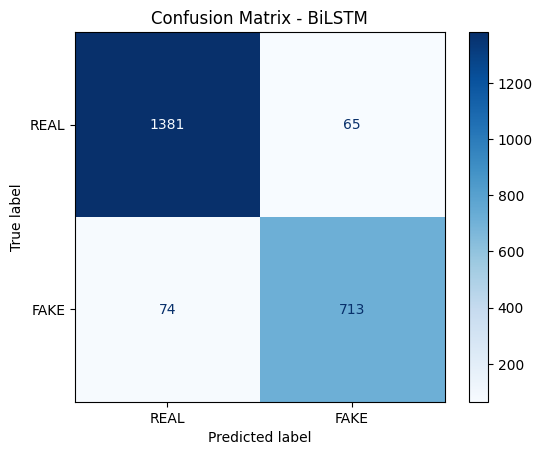

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["REAL", "FAKE"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - BiLSTM")
plt.show()

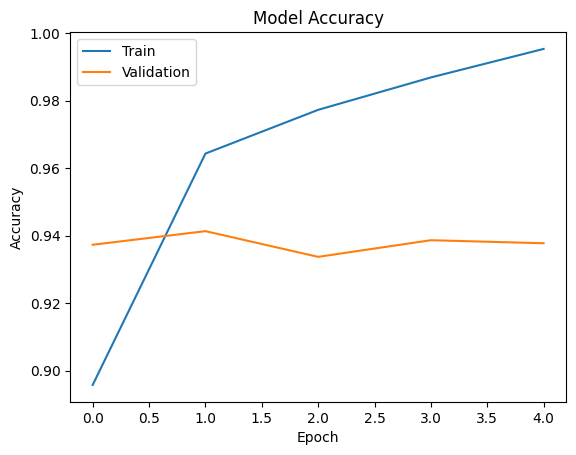

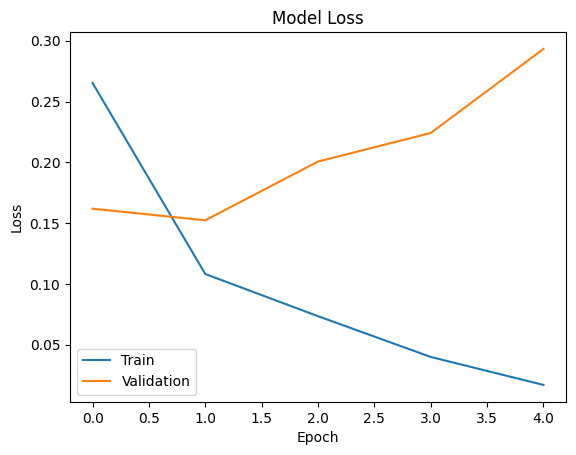

In [13]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [11]:
# lưu model
model.save("bilstm_fake_news.h5")

In [12]:
# test bài báo mới
sample_text = """
WHO xác nhận vaccine mới có hiệu quả chống biến thể mới của COVID-19.
"""

seq = tokenizer.texts_to_sequences([sample_text])

pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

pred = model.predict(pad)

print(pred)

if pred > 0.5:
    print("FAKE NEWS")
else:
    print("REAL NEWS")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
[[0.00078648]]
REAL NEWS
